# Question 5: How many sets are typically played in a tennis match?

Using `home_team_score` and `away_team_score`

In [24]:
%pip install seaborn
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
MINI_PROJECT_ROOT = Path.cwd().parents[2]

DATA_ROOT = (
    MINI_PROJECT_ROOT
    / "Tennis Schema"
    / "tennis_data"
)

PROCESSED_ROOT = DATA_ROOT / "processed"

print(PROCESSED_ROOT)

d:\Learning\Daneshkar\Statistics\Stat with Python\Mini Project\Tennis Schema\tennis_data\processed


In [26]:
TEAM_DATA_ROOT = DATA_ROOT / "Data"

print((TEAM_DATA_ROOT / "away_team_score.parquet").exists())
print((TEAM_DATA_ROOT / "home_team_score.parquet").exists())

True
True


In [27]:
home_score = pd.read_parquet(TEAM_DATA_ROOT / "home_team_score.parquet")
away_score = pd.read_parquet(TEAM_DATA_ROOT / "away_team_score.parquet")
home_score.head()

,match_id,current_score,display_score,period_1,period_2,period_3,period_4,period_5,period_1_tie_break,period_2_tie_break,period_3_tie_break,period_4_tie_break,period_5_tie_break,normal_time,snapshot_date
0,11974049,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-03
1,11974049,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-04
2,11974049,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-05
3,11974052,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-02
4,11974052,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-03


The early periods are NaN and we can access them by using the latest snapshot.

In [28]:
home_latest = (home_score.sort_values("snapshot_date").drop_duplicates(subset="match_id", keep="last"))

home_latest.head()

,match_id,current_score,display_score,period_1,period_2,period_3,period_4,period_5,period_1_tie_break,period_2_tie_break,period_3_tie_break,period_4_tie_break,period_5_tie_break,normal_time,snapshot_date
303,12018083,0.0,0.0,0.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-01
272,12017656,0.0,0.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-01
271,12017648,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-01
270,12017539,1.0,1.0,4.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-01
269,12017533,2.0,2.0,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-01


In [29]:
away_latest = (away_score.sort_values("snapshot_date").drop_duplicates(subset='match_id', keep='last'))

away_latest.head()

,match_id,current_score,display_score,period_1,period_2,period_3,period_4,period_5,period_1_tie_break,period_2_tie_break,period_3_tie_break,period_4_tie_break,period_5_tie_break,normal_time,snapshot_date
251,12017488,0.0,0.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-01
678,12022305,2.0,2.0,6.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-01
677,12022295,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-01
674,12022262,2.0,2.0,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-01
673,12022251,2.0,2.0,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-01


In [30]:
set_columns = ["period_1", "period_2", "period_3", "period_4", "period_5"]

home_latest["sets_played"] = home_latest[set_columns].count(axis=1) #axis=1 does not count the null amounts

home_latest[["match_id", "sets_played"]].head()

,match_id,sets_played
303,12018083,2
272,12017656,2
271,12017648,2
270,12017539,3
269,12017533,2


In [31]:
home_latest["sets_played"].value_counts().sort_index()

sets_played
0      680
1      119
2    11622
3     4452
Name: count, dtype: int64

In [32]:
typical_sets = home_latest.loc[home_latest["sets_played"] > 0,"sets_played"].mode()[0]

print("Typical number of sets played:", typical_sets)

Typical number of sets played: 2


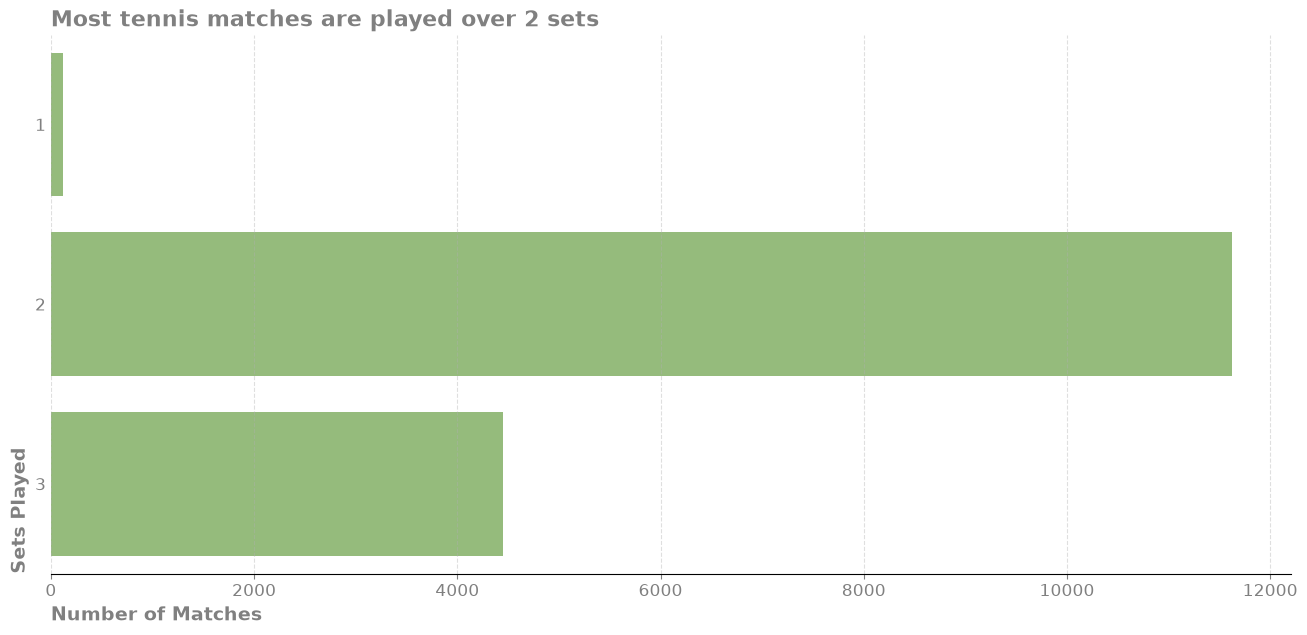

In [33]:
sets_distribution = (
    home_latest.loc[home_latest["sets_played"] > 0, "sets_played"]
    .value_counts()
    .sort_index()
    .rename_axis("sets_played")
    .reset_index(name="match_count"))

fig, ax = plt.subplots(figsize=(16, 7))

sns.barplot(
    data=sets_distribution,
    y="sets_played",
    x="match_count",
    color="#93C572",
    legend=False,
    orient="h",
    ax=ax)

ax.spines[["right", "left", "top"]].set_visible(False)

ax.set_title(
    "Most tennis matches are played over 2 sets",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=16)

ax.set_xlabel(
    "Number of Matches",
    weight="bold",
    color="gray",
    loc="left",
    fontsize=14)

ax.set_ylabel(
    "Sets Played",
    weight="bold",
    color="gray",
    loc="bottom",
    fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")
ax.tick_params(axis="y", which="major", length=0)

ax.grid(axis="x", linestyle="dashed", alpha=0.4)

plt.show()